# Data Inspection

This notebook profiles the car dataset before analysis or modeling. It checks the dataset structure, data quality, distributions, categorical values, possible outliers, and the first derived feature used for later analysis.

The notebook keeps the original data in `df` until the cleaning step, then creates `df_clean` without exact duplicate rows.

In [34]:
import pandas as pd
import numpy as np
df = pd.read_csv("C:\\Users\\omare\\OneDrive\\Desktop\\python project\\CAR DETAILS FROM CAR DEKHO.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


## 1. Load the Dataset

The dataset is loaded into `df`. The first preview confirms that the file was read successfully and gives an initial view of the available columns and records.

In [3]:
df.shape

(4340, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


## 2. Inspect Dataset Structure and Quality

These checks establish the number of rows and columns, the data types, and whether missing values or exact duplicate records are present. This is the core data-quality review before any transformation.

In [8]:
df.isnull().any()

name             False
year             False
selling_price    False
km_driven        False
fuel             False
seller_type      False
transmission     False
owner            False
dtype: bool

In [10]:
df.duplicated().any()

np.True_

In [11]:
df.duplicated().sum()

np.int64(763)

In [12]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [13]:
df.describe(include='object')

,name,fuel,seller_type,transmission,owner
count,4340,4340,4340,4340,4340
unique,1491,5,3,2,5
top,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner
freq,69,2153,3244,3892,2832


In [14]:
duplicated_rows = df[df.duplicated(keep = False)]
duplicated_rows.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [15]:
df.drop_duplicates().shape

(3577, 8)

## 3. Review Categorical Values

Value counts show the distinct categories and their frequencies for fuel type, seller type, transmission, and owner history. This helps identify unexpected labels and imbalanced categories.

In [17]:
categorical_columns = [
    "fuel",
    "seller_type",
    "transmission",
    "owner"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts())


fuel:
fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64

seller_type:
seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, dtype: int64

transmission:
transmission
Manual       3892
Automatic     448
Name: count, dtype: int64

owner:
owner
First Owner             2832
Second Owner            1106
Third Owner              304
Fourth & Above Owner      81
Test Drive Car            17
Name: count, dtype: int64


## 4. Explore Distributions and Potential Outliers

The histogram view and summary tables provide a quick sense of the numerical ranges, skew, and unusual records. The high-mileage review is an inspection step rather than an automatic decision to remove those observations.

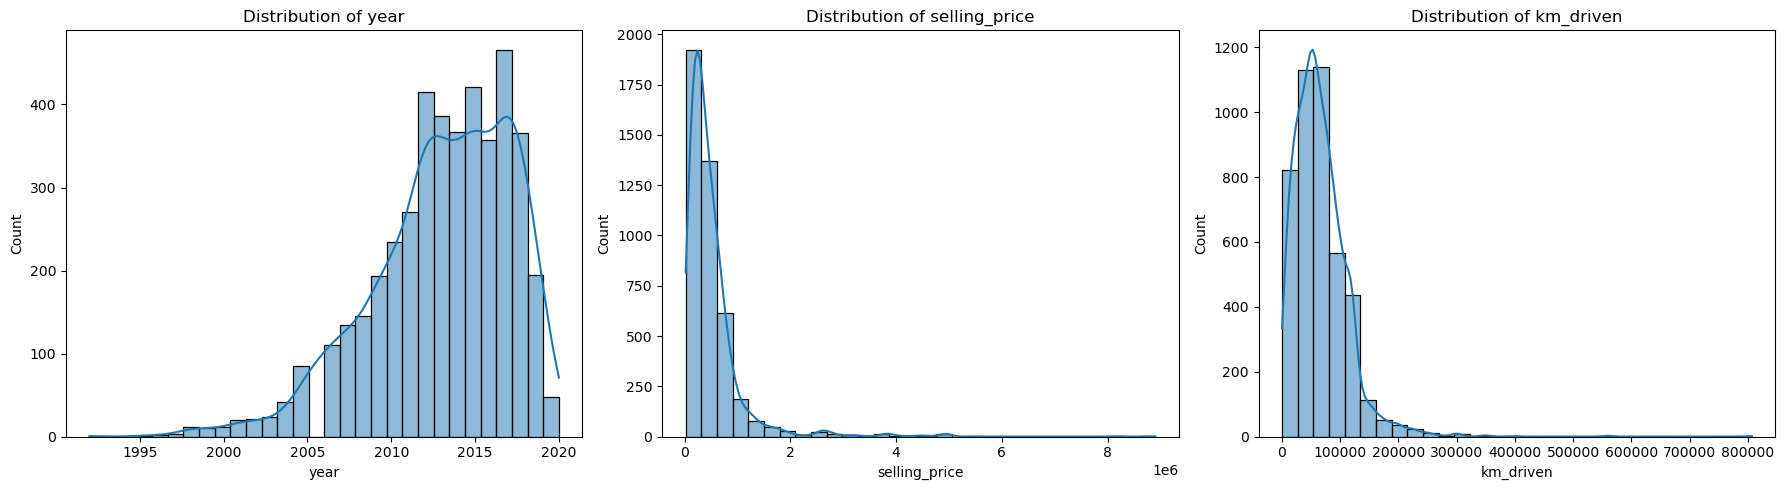

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_columns = ["year", "selling_price", "km_driven"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for column, ax in zip(numeric_columns, axes):
    sns.histplot(data=df, x=column, bins=30, kde=True, ax=ax)
    ax.set_title(f"Distribution of {column}")

plt.tight_layout()
plt.show()

In [19]:
df["owner"].value_counts()

owner
First Owner             2832
Second Owner            1106
Third Owner              304
Fourth & Above Owner      81
Test Drive Car            17
Name: count, dtype: int64

In [20]:
print("Exact duplicate rows:", df.duplicated().sum())
print("Rows after removing exact duplicates:", df.drop_duplicates().shape[0])

Exact duplicate rows: 763
Rows after removing exact duplicates: 3577


In [21]:
df[["year", "selling_price", "km_driven"]].agg(
    ["min", "max", "mean", "median"]
).round(2)

,year,selling_price,km_driven
min,1992.00,20000.00,1.00
max,2020.00,8900000.00,806599.00
mean,2013.09,504127.31,66215.78
median,2014.00,350000.00,60000.00


In [22]:
df.nlargest(10, "selling_price")[
    ["name", "year", "selling_price", "km_driven", "fuel", "owner"]
]

,name,year,selling_price,km_driven,fuel,owner
3872,Audi RS7 2015-2019 Sportback Performance,2016,8900000,13000,Petrol,First Owner
89,Mercedes-Benz S-Class S 350d Connoisseurs Edition,2017,8150000,6500,Diesel,First Owner
3969,Mercedes-Benz GLS 2016-2020 350d 4MATIC,2016,5500000,77350,Diesel,First Owner
555,BMW X5 xDrive 30d xLine,2019,4950000,30000,Diesel,First Owner
574,BMW X5 xDrive 30d xLine,2019,4950000,30000,Diesel,First Owner
593,BMW X5 xDrive 30d xLine,2019,4950000,30000,Diesel,First Owner
612,BMW X5 xDrive 30d xLine,2019,4950000,30000,Diesel,First Owner
900,BMW X5 xDrive 30d xLine,2019,4950000,30000,Diesel,First Owner
919,BMW X5 xDrive 30d xLine,2019,4950000,30000,Diesel,First Owner
1023,BMW X5 xDrive 30d xLine,2019,4950000,30000,Diesel,First Owner


In [23]:
df.nlargest(10, "km_driven")[
    ["name", "year", "selling_price", "km_driven", "fuel", "owner"]
]

,name,year,selling_price,km_driven,fuel,owner
1243,Maruti Swift VXI BSIII,2009,250000,806599,Petrol,First Owner
525,Maruti SX4 S Cross DDiS 320 Delta,2016,665000,560000,Diesel,First Owner
4184,Maruti SX4 S Cross DDiS 320 Delta,2016,665000,560000,Diesel,First Owner
3679,Toyota Innova 2.5 G (Diesel) 7 Seater BS IV,2006,400000,400000,Diesel,Third Owner
69,Chevrolet Tavera Neo LS B3 - 7(C) seats BSIII,2010,280000,350000,Diesel,Second Owner
2394,Toyota Innova 2.5 V Diesel 8-seater,2009,350000,350000,Diesel,First Owner
3718,Toyota Innova 2.5 GX 8 STR BSIV,2009,420000,347089,Diesel,First Owner
1674,Volkswagen Jetta 2.0 TDI Comfortline,2011,350000,312000,Diesel,Third Owner
1101,Tata Indica DLS,2006,85000,300000,Diesel,Second Owner
1659,Toyota Innova 2.5 G (Diesel) 8 Seater BS IV,2006,229999,300000,Diesel,First Owner


## 5. Create the Clean Working Copy

After reviewing the original records, the notebook creates `df_clean` by removing exact duplicates. Keeping `df_raw` preserves a reference to the original row count and makes the cleaning impact transparent.

In [35]:
# Keep the original dataset unchanged so we can compare it with the cleaned version later
df_raw = df.copy()
# Create a working copy without exact duplicate rows
df_clean = df.drop_duplicates().copy()
print("Original rows:", len(df_raw))
print("Rows after removing duplicates:", len(df_clean))
print("Duplicates remaining:", df_clean.duplicated().sum())

Original rows: 4340
Rows after removing duplicates: 3577
Duplicates remaining: 0


In [26]:
# Inspect records with unusually high mileage
df_clean[df_clean["km_driven"] > 300000][
    ["name", "year", "selling_price", "km_driven", "owner"]
].sort_values("km_driven", ascending=False)

,name,year,selling_price,km_driven,owner
1243,Maruti Swift VXI BSIII,2009,250000,806599,First Owner
525,Maruti SX4 S Cross DDiS 320 Delta,2016,665000,560000,First Owner
3679,Toyota Innova 2.5 G (Diesel) 7 Seater BS IV,2006,400000,400000,Third Owner
69,Chevrolet Tavera Neo LS B3 - 7(C) seats BSIII,2010,280000,350000,Second Owner
2394,Toyota Innova 2.5 V Diesel 8-seater,2009,350000,350000,First Owner
3718,Toyota Innova 2.5 GX 8 STR BSIV,2009,420000,347089,First Owner
1674,Volkswagen Jetta 2.0 TDI Comfortline,2011,350000,312000,Third Owner


In [27]:
print("Oldest manufacturing year:", df_clean["year"].min())
print("Newest manufacturing year:", df_clean["year"].max())

df_clean["year"].value_counts().sort_index()

Oldest manufacturing year: 1992
Newest manufacturing year: 2020


year
1992      1
1995      1
1996      2
1997      3
1998      9
1999      9
2000     12
2001     16
2002     18
2003     22
2004     38
2005     61
2006     93
2007    117
2008    129
2009    169
2010    210
2011    247
2012    338
2013    298
2014    321
2015    332
2016    283
2017    346
2018    295
2019    162
2020     45
Name: count, dtype: int64

## 6. Derive Car Age for Later Analysis

The newest manufacturing year in the cleaned data is used as a reference point for a simple `car_age` feature. The following checks confirm its range and whether the derivation introduced missing values.

In [36]:
REFERENCE_YEAR = df_clean["year"].max()

df_clean["car_age"] = REFERENCE_YEAR - df_clean["year"]

df_clean[["name", "year", "car_age"]].head(10)

,name,year,car_age
0,Maruti 800 AC,2007,13
1,Maruti Wagon R LXI Minor,2007,13
2,Hyundai Verna 1.6 SX,2012,8
3,Datsun RediGO T Option,2017,3
4,Honda Amaze VX i-DTEC,2014,6
5,Maruti Alto LX BSIII,2007,13
6,Hyundai Xcent 1.2 Kappa S,2016,4
7,Tata Indigo Grand Petrol,2014,6
8,Hyundai Creta 1.6 VTVT S,2015,5
9,Maruti Celerio Green VXI,2017,3


In [30]:
print("Reference year:", REFERENCE_YEAR)
print("Minimum car age:", df_clean["car_age"].min())
print("Maximum car age:", df_clean["car_age"].max())
print("Missing car ages:", df_clean["car_age"].isnull().sum())

Reference year: 2020
Minimum car age: 0
Maximum car age: 28
Missing car ages: 0


## 7. Check a Basic Relationship

The correlation between car age and selling price is included as an initial diagnostic. It can guide the deeper relationship analysis in the separate exploratory-analysis notebook, but it does not establish causation.

In [31]:
df_clean[["car_age", "selling_price"]].corr()

,car_age,selling_price
car_age,1.00000,-0.42426
selling_price,-0.42426,1.00000


## 8. Export the Inspected Dataset

The cleaned dataset, including the derived `car_age` column, is written to a CSV file for reuse in the next notebook. The original `df` is not overwritten.

In [37]:
df_clean.to_csv("C:\\Users\\omare\\OneDrive\\Desktop\\python project\\cleaned_car_data.csv", index=False)